<a href="https://colab.research.google.com/github/LuGorr/NLP-Assignments/blob/main/A1/Assignment_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Group members

|  Name   |  Surname   |     Email                            |    Student ID                                             |
| :-----: | :--------: | :----------------------------------: | :-----------------------------------------------------: |
| Ludovico  | Gorrieri   | `ludovico.gorrieri@studio.unibo.it`   |  0001199160 |
| Alessandro  | Capialbi | `alessandro.capialbi@studio.unibo.it`  | 0001191564 |
| Faezeh  | Sarlakifar | `faezeh.sarlakifar@studio.unibo.it`  | 0001164608 |

## Task 1 & 2

### Download the dataset and manage imports

In [1]:
# !wget https://github.com/nlp-unibo/nlp-course-material/tree/main/2025-2026/Assignment%201/data

In [2]:
!git clone https://github.com/nlp-unibo/nlp-course-material.git
%cd "nlp-course-material/2025-2026/Assignment 1"
!pip install -qq gensim
print("\ngensim installed!")
!pip install -qq plotly
print("plotly installed!")
!pip install -qq nltk
print("nltk installed!")
!pip install -qq transformers
print("transformers installed!")
!pip install -qq datasets
print("datasets installed!")
!pip install -qq accelerate -U
print("accelerate installed!")
!pip install -qq evaluate
print("evaluate installed!")
!pip install -qq bitsandbytes
print("bitsandbytes installed!")
!pip install -qq wandb
print("wandb installed!")

fatal: destination path 'nlp-course-material' already exists and is not an empty directory.
/tf/notebooks/Uni/magistrale/NLP/NLP-Assignments/A1/nlp-course-material/2025-2026/Assignment 1

gensim installed!
plotly installed!
nltk installed!
transformers installed!
datasets installed!
accelerate installed!
evaluate installed!
bitsandbytes installed!
wandb installed!


In [3]:
# --- Standard Library & Utilities ---
import os
import sys
import re
import json
import gc
import random
from random import shuffle
from collections import Counter
from itertools import product

# --- Data Science & Numerics ---
import numpy as np
import pandas as pd

# --- NLP (NLTK & Gensim) ---
import nltk
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag
from nltk.corpus import wordnet
from nltk.tokenize import (word_tokenize, 
                            sent_tokenize, 
                            WhitespaceTokenizer)
import gensim
import gensim.downloader as gloader
from gensim.models import KeyedVectors

# --- Plotting & Visualization ---
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.io as pio

# --- Scikit-Learn & Tracking ---
from sklearn.metrics import (f1_score, precision_score, recall_score,
                             classification_report, confusion_matrix, accuracy_score)
import wandb

# --- TensorFlow & Keras ---
import tensorflow as tf
import keras
from tensorflow.keras import layers, models, optimizers, regularizers
from tensorflow.keras.callbacks import ReduceLROnPlateau, Callback
from tensorflow.keras import backend as K
from tqdm.keras import TqdmCallback
tf_data = tf.data
os.environ["KERAS_BACKEND"] = "tensorflow"

# --- PyTorch & HuggingFace ---
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from datasets import Dataset
from transformers import (AutoTokenizer, 
                          AutoModelForSequenceClassification,
                          get_linear_schedule_with_warmup)

2025-12-22 18:13:54.874608: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE3 SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/usr/local/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### **Tweet Preprocessing and Label Aggregation Script**

This script prepares the dataset of tweets for NLP tasks.
It handles text cleaning, tokenization, lemmatization, and label aggregation for supervised learning.
Below is a detailed explanation of each section.

#### 1. Importing Required Libraries:

    a) pandas / numpy → for data manipulation.
    b) re → regular expressions for text cleaning.
    c) nltk → for tokenization, POS tagging, and lemmatization.
    d) Counter → to count occurrences of labels and select the majority vote.

#### 2. Preparing NLTK Resources:

    This block ensures that all required NLTK corpora and models are available locally.
    If a resource is missing, it is automatically downloaded.

#### 3. Initializing Tools:

    WhitespaceTokenizer → splits text based on spaces (useful after cleaning).
    WordNetLemmatizer → reduces words to their base or dictionary form using WordNet.

#### 4. Helper Function: get_wordnet_key(pos_tag):
    This function maps Penn Treebank POS tags (e.g., NN, VB, JJ) to WordNet’s format (noun, verb, adjective, adverb).
    This step is essential because WordNetLemmatizer requires the part of speech to perform accurate lemmatization.

#### 5. Lemmatization Function: lem_text(row):
    Reduces words to their dictionary form (lemma) using POS information.
    
    This function:

    1) Tokenizes the tweet into words.
    2) Assigns POS tags using NLTK’s pos_tag.
    3) Lemmatizes each word according to its part of speech.
    4) Returns the lemmatized tweet as a single string.

#### 6. Cleaning Function: cleaner(row):

    Purpose: Remove noise and standardize text before analysis.

    Steps:

    1) lower(): Converts all text to lowercase
    2) Remove URLs: Regex https?:\/\/.\S+ removes URLs and links
    3) Remove mentions & hashtags:	Regex [@#].\S+ removes @user and #topic
    4) Remove emojis/symbols: Unicode ranges cover emoticons, flags, pictographs
    5) Remove non-alphanumeric:	Keeps only letters, digits, and spaces
    6) Normalize whitespace:	Collapses multiple spaces into one

#### 7. Label Aggregation:

    This part aggregates multiple label votes for a tweet into a single numeric label.

    How it works:

    1) For each row, it collects all values in labels_task2 except "UNKNOWN".
    2) Uses Counter to find the most common label (majority vote).
    3) Maps that label to a numerical ID using the mapping dictionary.

#### Summary

    This script prepares tweets by performing:

    1) cleaner():	Remove unwanted characters and normalize text
    2) lem_text(): Lemmatize words for consistent representation
    3) aggregator(): Convert multiple annotations into a single label

    Together, these functions create a clean, normalized, and labeled dataset,
    ideal for tasks like text classication that we will perform.


In [4]:
# Prepare NLTK
resources = [
    ('corpora/omw-1.4', 'omw-1.4'),
    ('corpora/wordnet', 'wordnet'),
    ('taggers/averaged_perceptron_tagger', 'averaged_perceptron_tagger'),
    ('taggers/averaged_perceptron_tagger_eng', 'averaged_perceptron_tagger_eng'),
    ('tokenizers/punkt_tab', 'punkt_tab'),
    ('tokenizers/punkt', 'punkt')
]

for resource_path, download_name in resources:
    try:
        nltk.data.find(resource_path)
    except LookupError:
        nltk.download(download_name, quiet=True)

tokenizer = WhitespaceTokenizer()
lemmatizer = WordNetLemmatizer()


def get_wordnet_key(pos_tag):
    if pos_tag.startswith('J'):
        return wordnet.ADJ
    elif pos_tag.startswith('V'):
        return wordnet.VERB
    elif pos_tag.startswith('N'):
        return wordnet.NOUN
    elif pos_tag.startswith('R'):
        return wordnet.ADV
    else:
        return 'n'

# Lemmatize a row's tweet
def lem_text(row):
    tokens = tokenizer.tokenize(row.tweet)
    tagged = pos_tag(tokens)
    words = [lemmatizer.lemmatize(word, get_wordnet_key(tag))
             for word, tag in tagged]
    return " ".join(words)

# Normalization: clean a row's tweet
def cleaner(row):
    text = row.tweet
    text = text.lower()
    text = re.sub(r'https?:\/\/.\S+', '', text)
    text = re.sub(r'[@#].\S+', '', text)
    text = re.sub(
        "["
            u"\U0001F600-\U0001F64F"  # Emoticons
            u"\U0001F300-\U0001F5FF"  # Symbols & pictographs
            u"\U0001F680-\U0001F6FF"  # Transport & map symbols
            u"\U0001F1E0-\U0001F1FF"  # Flags
                                    "]+", '', text
    )
    text = re.sub(r'[^a-z^0-9^\s]*', '', text)
    text = ' '.join(text.split())
    return text

# Aggregate the labels (labels_task2)
aggregator = lambda row: \
    mapping[Counter([vote for vote in row.labels_task2 if vote != "UNKNOWN"]).most_common(1)[0][0]]

mapping = {
    '-': 0,
    'DIRECT': 1,
    'JUDGEMENTAL': 2,
    'REPORTED': 3
}

### Clean, split and lemmatize the dataset.

In [5]:
# Load the files
with open("data/training.json", "r") as tr, \
     open("data/validation.json", "r") as te, \
     open("data/test.json", "r") as va:
    train_json = json.load(tr)
    val_json = json.load(te)
    test_json = json.load(va)

# Create the dataframes (setting the index to id_EXIST)
dts = {
    "train": pd.DataFrame.from_dict(train_json, orient="index").set_index("id_EXIST"),
    "test": pd.DataFrame.from_dict(test_json, orient="index").set_index("id_EXIST"),
    "val": pd.DataFrame.from_dict(val_json, orient="index").set_index("id_EXIST")
}

# Unnecessary columns
drop_cols = ["number_annotators", "annotators", "gender_annotators",
    "age_annotators", "labels_task1", "labels_task3", "split", "lang"]

# Clean and lemmatize the data
for name, df in dts.items():
    df = df[df.lang == "en"].copy() # Drop spanish.

    df = df.drop(columns=drop_cols) # Drop unnecessary cols.

    df["labels"] = df.apply(aggregator, axis=1) # Aggregate the labels (maj. voting).
    df = df.drop(columns="labels_task2")

    for func in [cleaner, lem_text]:
        df["tweet"] = df.apply(func, axis=1) # Clean the tweets.

    dts[name] = df

train, test, val = dts.values()

train.rename(columns={"labels": "label"}, inplace=True)
train.rename(columns={"tweet": "text"}, inplace=True)
val.rename(columns={"labels": "label"}, inplace=True)
val.rename(columns={"tweet": "text"}, inplace=True)
test.rename(columns={"labels": "label"}, inplace=True)
test.rename(columns={"tweet": "text"}, inplace=True)

## Task 3: Text Encoding

### Build the vocabulary

In [6]:
def plot_dists(train, test, extra_title=""):
    pio.renderers.default = "notebook_connected"
    label_map = {0: "NOT SEXIST", 1: "DIRECT", 2: "JUDGEMENTAL", 3: "REPORTED"}
    category_order = ["NOT SEXIST", "DIRECT", "JUDGEMENTAL", "REPORTED"]
    train_plot = train.copy()
    test_plot = test.copy()
    train_plot["dataset"] = "Training Set"
    test_plot["dataset"] = "Test Set"
    df_all = pd.concat([train_plot, test_plot])
    df_all["label_name"] = df_all["label"].map(label_map)
    df_counts = df_all.groupby(['dataset', 'label_name']).size().reset_index(name='counts')
    df_counts['percent'] = df_counts.groupby('dataset')['counts'].transform(lambda x: (x / x.sum()) * 100)
    fig = px.bar(
        df_counts,
        x="label_name",
        y="percent",
        color="label_name",
        facet_col_spacing=0.05,
        facet_col="dataset",
        category_orders={"label_name": category_order, "dataset": ["Training Set", "Test Set"]},
        color_discrete_sequence=px.colors.sequential.Plasma,
        text=df_counts['percent'].apply(lambda x: f'{x:.1f}%'), # Etichette precise
        labels={"label_name": "Class", "percent": "Percentage (%)"}
    )
    fig.update_layout(
        width=1000, height=500,
        showlegend=False,
        bargap=0.2,
        title_text="Class Distribution: Percentage of each Set " + extra_title,
        title_x=0.5
    )
    fig.for_each_annotation(lambda a: a.update(text=a.text.split("=")[-1]))
    fig.update_traces(textposition='outside') # Mette i numeri sopra le barre
    fig.update_yaxes(title_text="Percentage (%)", ticksuffix="%")
    fig.show()
    train_plot["text_length"] = train_plot["text"].apply(lambda x: len(x.split()))
    plt.figure(figsize=(10,5))
    sns.histplot(train_plot["text_length"], bins=30, kde=True, color="purple")
    plt.title("Distribution of Tweet Lengths (Training Set)")
    plt.xlabel("Number of Words")
    plt.ylabel("Frequency")
    plt.show()
    plt.figure(figsize=(8,5))
    sns.boxplot(x="label", y="text_length",hue="label", legend=False, data=train_plot, palette="viridis")
    plt.title("Tweet Length by Class")
    plt.xlabel("Class")
    plt.ylabel("Tweet Length (words)")
    plt.xticks([0,1,2,3], ['-', 'DIRECT', 'JUDGEMENTAL', 'REPORTED'])
    plt.show()

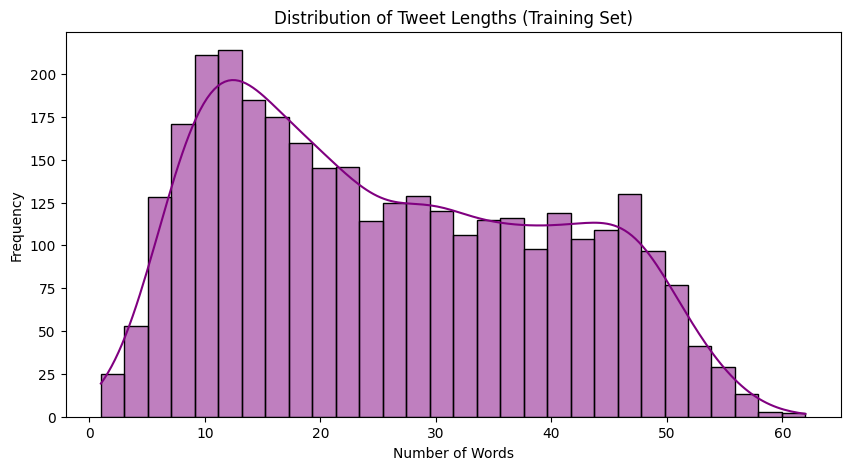

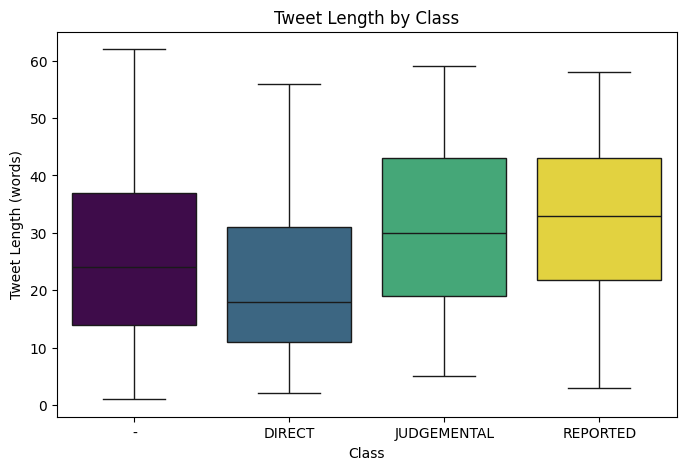

AUGMENTATION DONE!


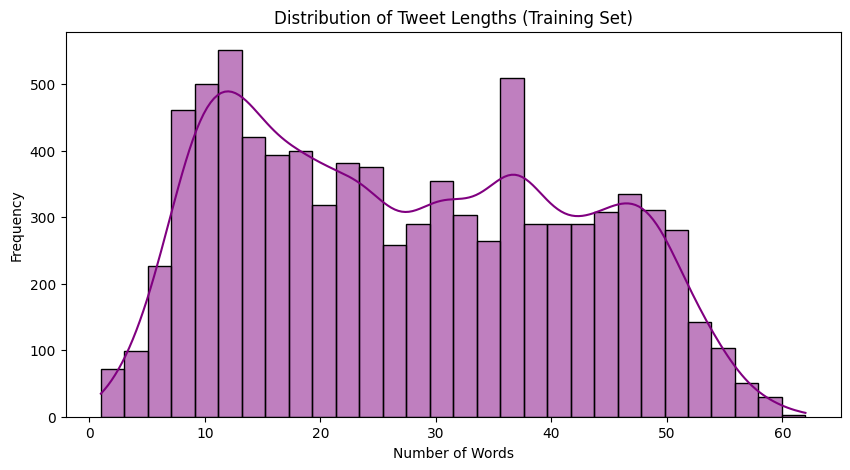

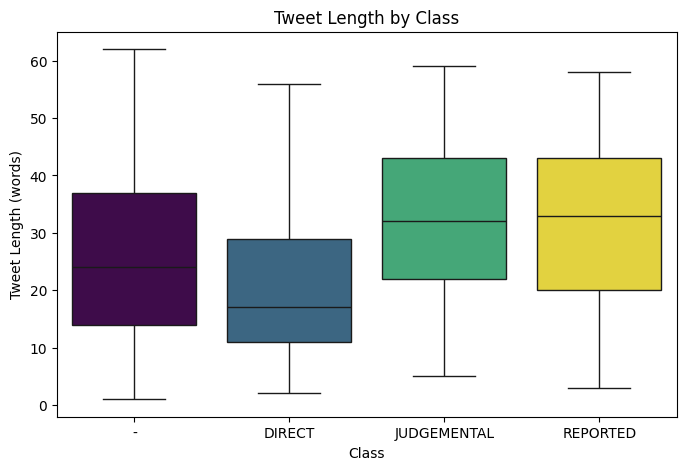

In [7]:
plot_dists(train, test, "(Before Augmentation)")
label_map = {0: "NOT SEXIST", 1: "DIRECT", 2: "JUDGEMENTAL", 3: "REPORTED"}

label_counts = [train.label[train.label == i].count() for i in label_map.keys()]
majority = np.argmax(label_counts)
for i in label_map:
  if i != majority:
    for _ in range(label_counts[majority] - label_counts[i]):
      train = pd.concat([pd.DataFrame(train[train.label == i].sample(1), \
                          columns=train.columns), train], ignore_index=True)
        
train = train.sample(frac=1).reset_index(drop=True)
print("AUGMENTATION DONE!")
plot_dists(train, test, "(After Augmentation)")

In [8]:
vectorizer = layers.TextVectorization(max_tokens=20000)
vectorizer.adapt(train["text"])

I0000 00:00:1766427247.759553   57179 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15474 MB memory:  -> device: 0, name: AMD Radeon RX 7800 XT, pci bus id: 0000:2d:00.0


In [9]:
# Create a TensorFlow Dataset for training data
# Each batch contains 64 examples for efficient training
train_ds = tf.data.Dataset.from_tensor_slices((train["text"], train["label"])) \
    .map(lambda x, y: (vectorizer(x), y)) \
    .padded_batch(32) \
    .prefetch(tf.data.AUTOTUNE)

# Create a TensorFlow Dataset for validation data
valid_ds = tf.data.Dataset.from_tensor_slices((val["text"], val["label"])) \
    .map(lambda x, y: (vectorizer(x), y)) \
    .padded_batch(32) \
    .prefetch(tf.data.AUTOTUNE)
# Create a TensorFlow Dataset for test data
test_ds = tf.data.Dataset.from_tensor_slices((test["text"], test["label"])) \
    .map(lambda x, y: (vectorizer(x), y)).padded_batch(len(test)).prefetch(tf.data.AUTOTUNE)


In [10]:
vocab = vectorizer.get_vocabulary()
print(vocab[:10])

['', '[UNK]', 'be', 'the', 'a', 'to', 'and', 'woman', 'of', 'i']


The vectorizer has its vocabulary frozen after adapt().

When we apply it to the val or test set,

any word not seen during training will automatically be replaced with the OOV token (default **UNK**, index 1).

We do not need to manually preprocess or map OOV tokens, TensorFlow will handle it internally.

### Use GloVe Embedding vectors

#### Convert GloVe format to Word2Vec format

In [11]:
if 'google.colab' in sys.modules:
    from google.colab import drive
    drive.mount('/content/drive')
    glove_dst = "/content/drive/MyDrive/glove.twitter.27B.50d.txt"
else:
    glove_dst = "glove.twitter.27B.50d.txt"
glove_src = "glove.twitter.27B.50d.txt"

if os.path.exists(glove_dst):
    print("GloVe file already exists in Drive.")
else:
    print("Downloading GloVe file...")
    !wget http://nlp.stanford.edu/data/glove.twitter.27B.zip
    !unzip -q glove.twitter.27B.zip
    print("Copying GloVe file...")
    !cp "$glove_src" "$glove_dst"
    print("File copied successfully!")

glove_file = glove_dst

GloVe file already exists in Drive.


In [12]:
# Load GloVe into Gensim
twitter_glove = KeyedVectors.load_word2vec_format(glove_file, binary=False, no_header=True)

print(f"Loaded Twitter GloVe with {len(twitter_glove.key_to_index):,} tokens")

Loaded Twitter GloVe with 1,193,514 tokens


#### Build TensorFlow embedding matrix

In [13]:
vocab = vectorizer.get_vocabulary()
embedding_dim = twitter_glove.vector_size
embedding_matrix = np.zeros((len(vocab), embedding_dim))

### OOV handling

#### Random embedding initialization for OOV words

Then we will learn them by training

In [14]:
# Construct the embedding matrix using GloVe vectors or random initialization
# For each word in the vocabulary:
# - If the word exists in the pre-trained GloVe embeddings, use its vector.
# - Otherwise, initialize its vector with random values drawn from a normal distribution
#   (mean = 0, std = 0.6) to represent out-of-vocabulary (OOV) words.
count_0 = 0
count_1 = 0
for i, word in enumerate(vocab):
    if word in twitter_glove:
        embedding_matrix[i] = twitter_glove[word]
        count_0 += 1
    else:
        embedding_matrix[i] = np.random.normal(scale=0.6, size=(embedding_dim,))
        count_1 += 1
print(count_0)
print(count_1)

8446
2123


## Task 4 & 5

In [15]:
def get_callbacks(verbose):
    return [ReduceLROnPlateau(
      monitor='val_loss',
      factor=0.5,
      patience=3,
      min_lr=1e-6,
      verbose=verbose
  ), tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    mode='min',
    patience=5,
    restore_best_weights=True,
    verbose=verbose
    ), TqdmCallback(verbose=0)]

def build_model(stacked=False, lr=1e-3):
    model = models.Sequential([
        layers.Embedding(
            input_dim=len(vocab),
            output_dim=embedding_dim,
            weights=[embedding_matrix],
            mask_zero=True,
            trainable=True,
            name='encoder-embedding'
        ),
        layers.Bidirectional(
            layers.LSTM(LSTM_UNITS,
                        return_sequences=stacked,
                        kernel_regularizer=regularizers.l2(L2_FACTOR),
                        activation='leaky_relu',
                        recurrent_activation='sigmoid'
                       )
        ),
        #layers.LayerNormalization(),
        layers.Dropout(DROPOUT_RATE),
        layers.Bidirectional(
            layers.LSTM(LSTM_UNITS,
                        return_sequences=False,
                        kernel_regularizer=regularizers.l2(L2_FACTOR),
                        activation='leaky_relu',
                        recurrent_activation='sigmoid'
                        )
                       ) if stacked else layers.Identity(),
        #layers.LayerNormalization() if stacked else layers.Identity(),
        layers.Dropout(DROPOUT_RATE) if stacked else layers.Identity(),
        layers.Dense(
            64,
            activation = "leaky_relu",
            kernel_regularizer=regularizers.l2(L2_FACTOR)
        ),
        layers.Dropout(DROPOUT_RATE),
        layers.Dense(4, activation='softmax')
    ])

    model.compile(
        loss='sparse_categorical_crossentropy',
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr, clipvalue=1.0),
        metrics=['accuracy']
    )
    return model

def predict_batch(model, x):
    return model(x, training=False)

def evaluate_model(model, valid_ds, class_names=['NOT SEXIST', 'DIRECT', 'JUDGEMENTAL', 'REPORTED']):
    """
    Compute macro F1, precision, recall, and display classification report
    and confusion matrix on the validation set.
    """
    y_true = []
    y_pred_probs = []

    # Iterate over the validation dataset
    for x_batch, y_batch in valid_ds:
        # Get model predictions (probabilities) using the tf.function
        preds = predict_batch(model, x_batch)

        # Store true labels (ground truth)
        y_true.extend(y_batch.numpy())
        # Store predicted probabilities
        y_pred_probs.extend(preds.numpy())

    # Get the predicted class index (the one with the highest probability)
    y_pred = np.argmax(y_pred_probs, axis=1)

    # 1. Print the detailed Classification Report
    # This shows precision, recall, f1-score for each class
    print("\n--- Classification Report ---")
    print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))
    print("---------------------------------")

    # 2. Compute and display the Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)

    print("\nPlotting Confusion Matrix...")
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=[f'Pred {name}' for name in class_names],
                yticklabels=[f'True {name}' for name in class_names])
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.title('Confusion Matrix')
    plt.show()

    # 3. Calculate macro-averaged metrics
    # 'macro' calculates metrics for each label, and finds their unweighted mean.
    # This is crucial for imbalanced datasets.
    f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
    prec = precision_score(y_true, y_pred, average='macro', zero_division=0)
    rec = recall_score(y_true, y_pred, average='macro', zero_division=0)

    return f1, prec, rec


Training baseline model with seed 42...


  0%|                                                 | 0/30 [00:00<?, ?epoch/s]2025-12-22 18:14:54.365999: I external/local_xla/xla/service/service.cc:163] XLA service 0x7966d400a400 initialized for platform ROCM (this does not guarantee that XLA will be used). Devices:
2025-12-22 18:14:54.366020: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): AMD Radeon RX 7800 XT, AMDGPU ISA version: gfx1101
2025-12-22 18:14:54.410225: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-12-22 18:14:54.855745: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-12-22 18:14:54.855763: I external/local_xla/xla/service/gpu/a

Restoring model weights from the end of the best epoch: 30.


100%|█| 30/30 [01:20<00:00,  2.68s/epoch, accuracy=0.623, loss=1.02, val_accurac



--- Classification Report ---
              precision    recall  f1-score   support

  NOT SEXIST       0.71      0.53      0.61       185
      DIRECT       0.40      0.49      0.44        70
 JUDGEMENTAL       0.14      0.25      0.18        24
    REPORTED       0.15      0.21      0.17        33

    accuracy                           0.46       312
   macro avg       0.35      0.37      0.35       312
weighted avg       0.54      0.46      0.49       312

---------------------------------

Plotting Confusion Matrix...


2025-12-22 18:16:14.974246: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


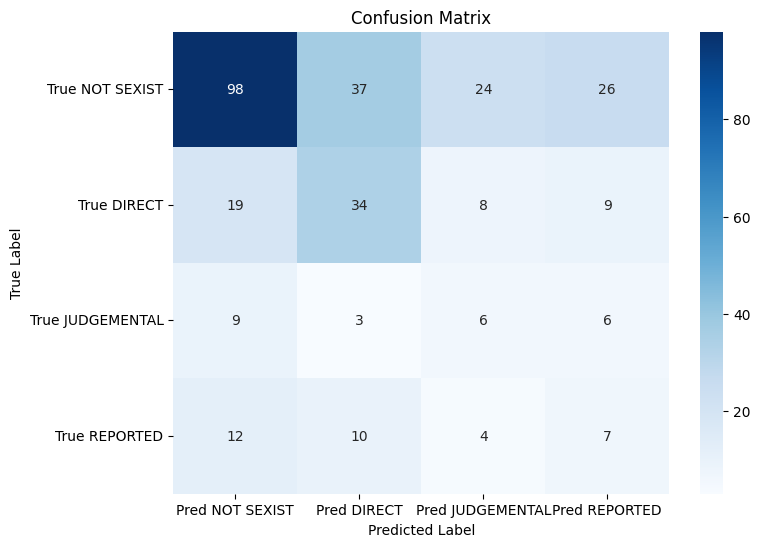


Training stacked model with seed 42...


 27%|▎| 8/30 [01:25<01:38,  4.47s/epoch, accuracy=0.264, loss=1.53, val_accuracy/usr/local/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning:

Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.

100%|█| 30/30 [01:54<00:00,  1.16s/epoch, accuracy=0.581, loss=1.08, val_accurac

Restoring model weights from the end of the best epoch: 30.


100%|█| 30/30 [01:54<00:00,  3.83s/epoch, accuracy=0.581, loss=1.08, val_accurac



--- Classification Report ---
              precision    recall  f1-score   support

  NOT SEXIST       0.82      0.51      0.63       185
      DIRECT       0.50      0.50      0.50        70
 JUDGEMENTAL       0.13      0.67      0.22        24
    REPORTED       0.29      0.06      0.10        33

    accuracy                           0.47       312
   macro avg       0.44      0.43      0.36       312
weighted avg       0.64      0.47      0.51       312

---------------------------------

Plotting Confusion Matrix...


2025-12-22 18:18:11.544717: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


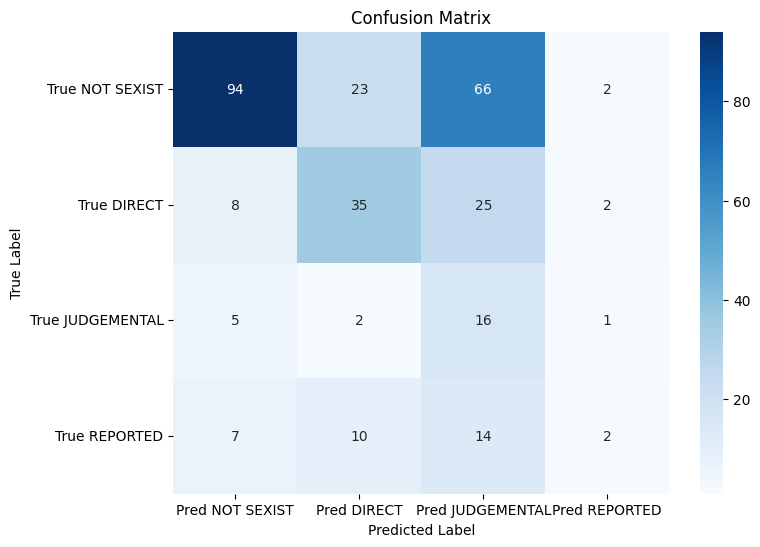


Training baseline model with seed 123...


 27%|▎| 8/30 [01:00<01:06,  3.04s/epoch, accuracy=0.292, loss=1.52, val_accuracy/usr/local/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning:

Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.

 60%|▌| 18/30 [01:09<00:07,  1.55epoch/s, accuracy=0.396, loss=1.39, val_accurac


Epoch 19: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.


 70%|▋| 21/30 [01:11<00:05,  1.53epoch/s, accuracy=0.409, loss=1.36, val_accurac

Epoch 21: early stopping
Restoring model weights from the end of the best epoch: 16.


 70%|▋| 21/30 [01:11<00:30,  3.39s/epoch, accuracy=0.409, loss=1.36, val_accurac



--- Classification Report ---
              precision    recall  f1-score   support

  NOT SEXIST       0.76      0.56      0.64       185
      DIRECT       0.47      0.66      0.55        70
 JUDGEMENTAL       0.17      0.54      0.26        24
    REPORTED       0.33      0.03      0.06        33

    accuracy                           0.52       312
   macro avg       0.43      0.45      0.38       312
weighted avg       0.61      0.52      0.53       312

---------------------------------

Plotting Confusion Matrix...


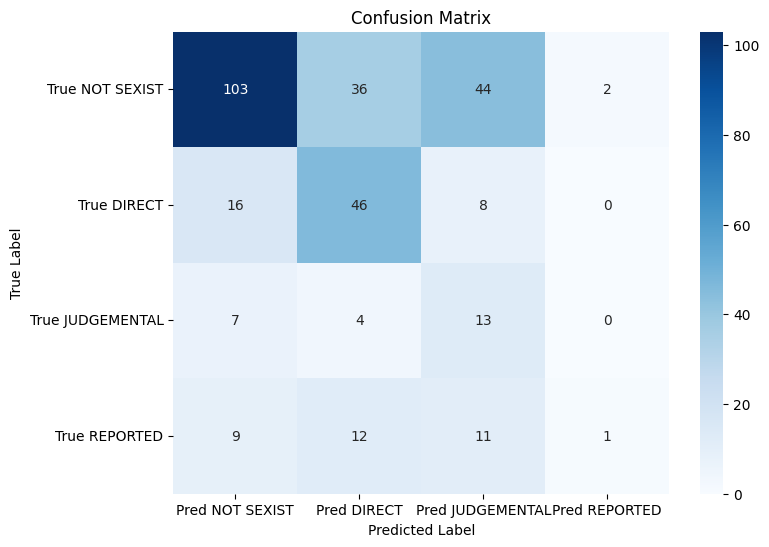


Training stacked model with seed 123...


 27%|▎| 8/30 [01:22<01:36,  4.37s/epoch, accuracy=0.289, loss=1.53, val_accuracy/usr/local/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning:

Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.

 90%|▉| 27/30 [01:47<00:03,  1.03s/epoch, accuracy=0.464, loss=1.19, val_accurac


Epoch 28: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.


100%|█| 30/30 [01:51<00:00,  1.17s/epoch, accuracy=0.508, loss=1.17, val_accurac

Epoch 30: early stopping
Restoring model weights from the end of the best epoch: 25.


100%|█| 30/30 [01:51<00:00,  3.72s/epoch, accuracy=0.508, loss=1.17, val_accurac



--- Classification Report ---
              precision    recall  f1-score   support

  NOT SEXIST       0.81      0.31      0.45       185
      DIRECT       0.29      0.93      0.44        70
 JUDGEMENTAL       0.00      0.00      0.00        24
    REPORTED       0.13      0.06      0.08        33

    accuracy                           0.40       312
   macro avg       0.31      0.33      0.24       312
weighted avg       0.56      0.40      0.38       312

---------------------------------

Plotting Confusion Matrix...


2025-12-22 18:21:17.464175: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


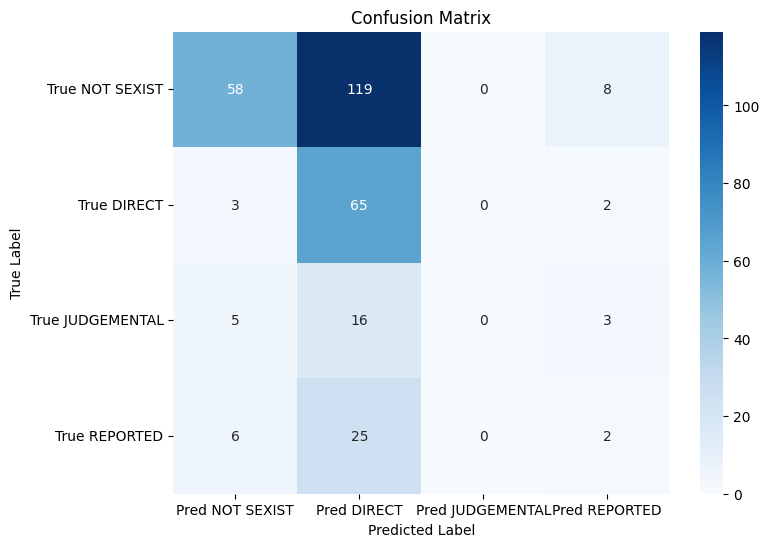


Training baseline model with seed 999...


 27%|▎| 8/30 [00:56<01:03,  2.88s/epoch, accuracy=0.298, loss=1.49, val_accuracy/usr/local/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning:

Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.

 67%|▋| 20/30 [01:06<00:06,  1.54epoch/s, accuracy=0.419, loss=1.35, val_accurac


Epoch 21: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.


 93%|▉| 28/30 [01:11<00:01,  1.72epoch/s, accuracy=0.498, loss=1.22, val_accurac


Epoch 29: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.


100%|█| 30/30 [01:12<00:00,  1.60epoch/s, accuracy=0.542, loss=1.18, val_accurac

Restoring model weights from the end of the best epoch: 30.


100%|█| 30/30 [01:12<00:00,  2.41s/epoch, accuracy=0.542, loss=1.18, val_accurac



--- Classification Report ---
              precision    recall  f1-score   support

  NOT SEXIST       0.75      0.56      0.64       185
      DIRECT       0.45      0.49      0.47        70
 JUDGEMENTAL       0.12      0.42      0.19        24
    REPORTED       0.24      0.12      0.16        33

    accuracy                           0.49       312
   macro avg       0.39      0.40      0.37       312
weighted avg       0.58      0.49      0.52       312

---------------------------------

Plotting Confusion Matrix...


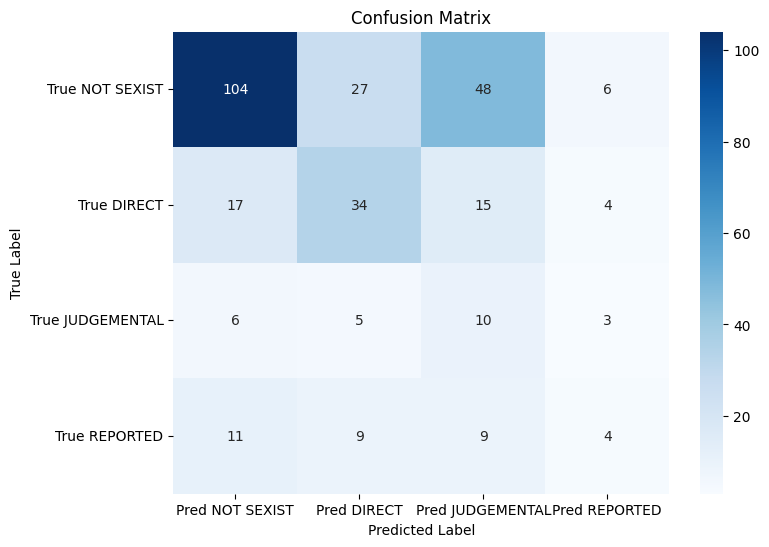


Training stacked model with seed 999...


 27%|▎| 8/30 [01:18<01:32,  4.21s/epoch, accuracy=0.243, loss=1.52, val_accuracy/usr/local/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning:

Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.

 57%|▌| 17/30 [01:32<00:18,  1.40s/epoch, accuracy=0.309, loss=1.44, val_accurac


Epoch 18: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.


 70%|▋| 21/30 [01:36<00:10,  1.21s/epoch, accuracy=0.348, loss=1.4, val_accuracy


Epoch 22: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.


...


Epoch 29: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.


100%|█| 30/30 [01:46<00:00,  1.19s/epoch, accuracy=0.398, loss=1.32, val_accurac

Restoring model weights from the end of the best epoch: 26.


100%|█| 30/30 [01:46<00:00,  3.56s/epoch, accuracy=0.398, loss=1.32, val_accurac



--- Classification Report ---
              precision    recall  f1-score   support

  NOT SEXIST       0.64      0.04      0.07       185
      DIRECT       0.34      0.81      0.47        70
 JUDGEMENTAL       0.11      0.17      0.14        24
    REPORTED       0.11      0.33      0.17        33

    accuracy                           0.25       312
   macro avg       0.30      0.34      0.21       312
weighted avg       0.47      0.25      0.18       312

---------------------------------

Plotting Confusion Matrix...


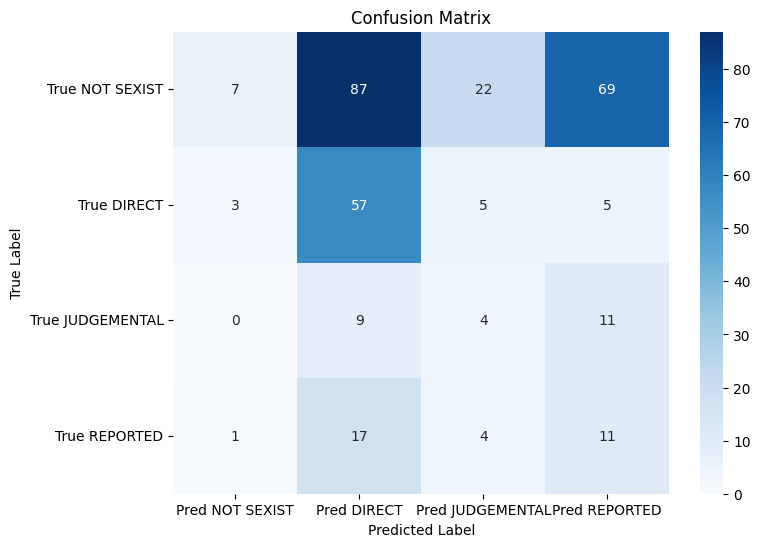


Retraining best base model with seed 123...


 27%|▎| 8/30 [00:56<01:00,  2.76s/epoch, accuracy=0.292, loss=1.52, val_accuracy/usr/local/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning:

Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.

 70%|▋| 21/30 [01:06<00:28,  3.18s/epoch, accuracy=0.409, loss=1.36, val_accurac



--- Classification Report ---
              precision    recall  f1-score   support

  NOT SEXIST       0.76      0.56      0.64       185
      DIRECT       0.47      0.66      0.55        70
 JUDGEMENTAL       0.17      0.54      0.26        24
    REPORTED       0.33      0.03      0.06        33

    accuracy                           0.52       312
   macro avg       0.43      0.45      0.38       312
weighted avg       0.61      0.52      0.53       312

---------------------------------

Plotting Confusion Matrix...


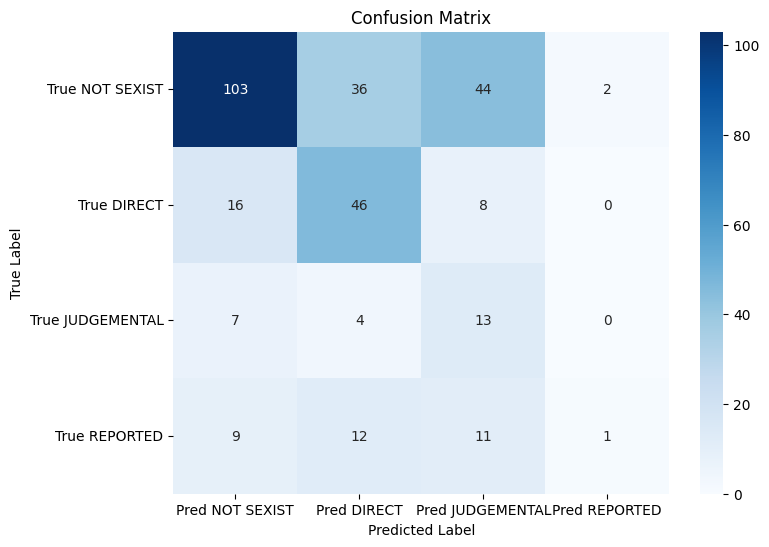

Best model saved as 'best_base_model.keras'

Retraining best stacked model with seed 42...


 27%|▎| 8/30 [01:12<01:22,  3.74s/epoch, accuracy=0.264, loss=1.53, val_accuracy/usr/local/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning:

Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.

100%|█| 30/30 [01:41<00:00,  3.37s/epoch, accuracy=0.518, loss=1.18, val_accurac



--- Classification Report ---
              precision    recall  f1-score   support

  NOT SEXIST       0.84      0.43      0.57       185
      DIRECT       0.45      0.56      0.50        70
 JUDGEMENTAL       0.12      0.62      0.20        24
    REPORTED       0.38      0.09      0.15        33

    accuracy                           0.44       312
   macro avg       0.45      0.43      0.35       312
weighted avg       0.65      0.44      0.48       312

---------------------------------

Plotting Confusion Matrix...


2025-12-22 18:27:11.166935: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


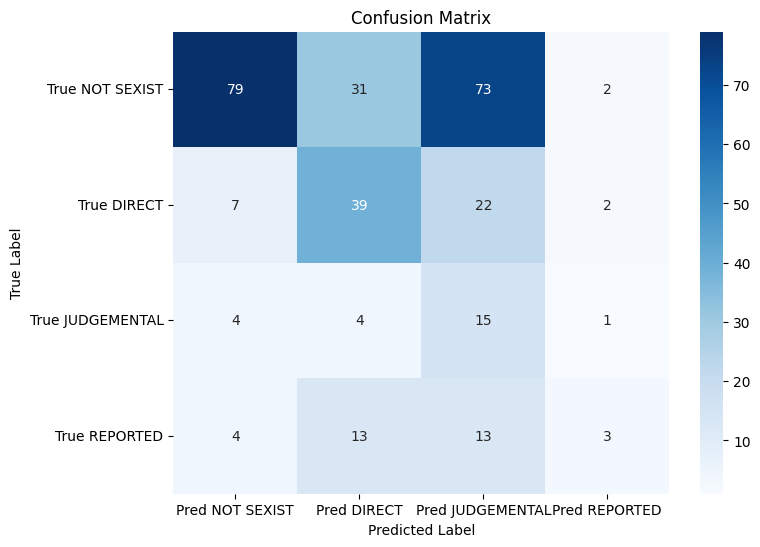

Best model saved as 'best_stacked_model.keras'


In [16]:
# Hyperparameters
LSTM_UNITS = 25 # Per LSTM layer.
DROPOUT_RATE = 0.7
LR = 1e-3
EPOCHS = 30
SEEDS = [42, 123, 999]
L2_FACTOR = 1e-3
classes = [0, 1, 2, 3]

f1_scores_base, precisions_base, recalls_base = [], [], []
f1_scores_stacked, precisions_stacked, recalls_stacked = [], [], []

for seed, stacked in list(product(SEEDS, [False, True])):
    print(f"\nTraining {"stacked" if stacked else "baseline"} model with seed {seed}...")
    tf.keras.utils.set_random_seed(seed)
    model = build_model(stacked, LR)
    
    model.fit(
        train_ds,
        validation_data=valid_ds,
        epochs=EPOCHS,
        steps_per_epoch=32,
        callbacks=get_callbacks(True),
        verbose=0
    )
    f1, prec, rec = evaluate_model(model, test_ds)
    del model
    if 'best_model' in locals(): del best_model
    K.clear_session()
    gc.collect()
    f1_scores_stacked.append(f1) if stacked else f1_scores_base.append(f1)
    precisions_stacked.append(prec) if stacked else precisions_base.append(prec)
    recalls_stacked.append(rec) if stacked else recalls_base.append(rec)

history_best = []
for stacked in [False, True]:
    best_seed = SEEDS[np.argmax(f1_scores_stacked if stacked else f1_scores_base)]
    print(f"\nRetraining best {"stacked" if stacked else "base"} model with seed {best_seed}...")
    tf.keras.utils.set_random_seed(best_seed)
    best_model = build_model(stacked, LR)
    history = best_model.fit(
        train_ds,
        validation_data=valid_ds,
        epochs=EPOCHS,
        steps_per_epoch=32,
        callbacks=get_callbacks(False),
        verbose=0

    )
    history_best.append(history.history)
    evaluation = evaluate_model(best_model, test_ds)
    best_model.save(f"best_{"stacked" if stacked else "base"}_model.keras")
    del best_model
    del history
    if 'best_model' in locals(): del best_model
    K.clear_session()
    gc.collect()
    print(f"Best model saved as 'best_{"stacked" if stacked else "base"}_model.keras'")

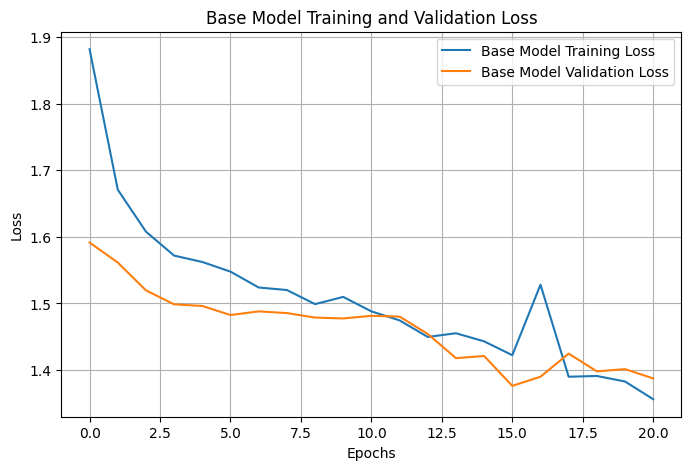

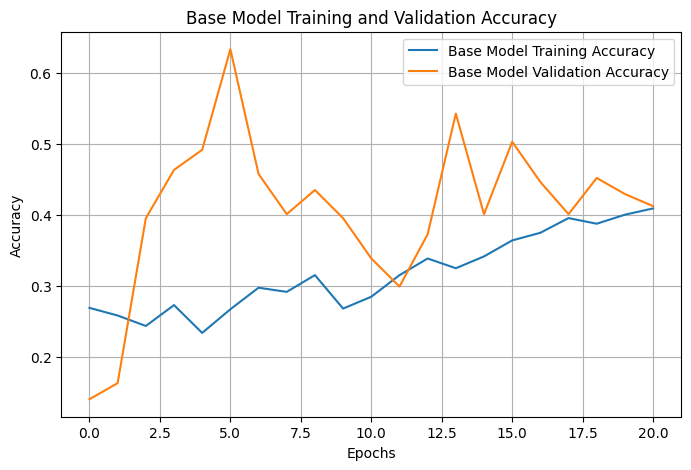

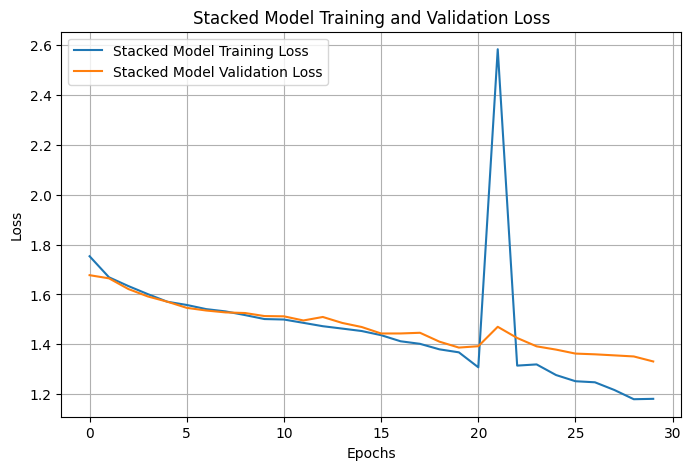

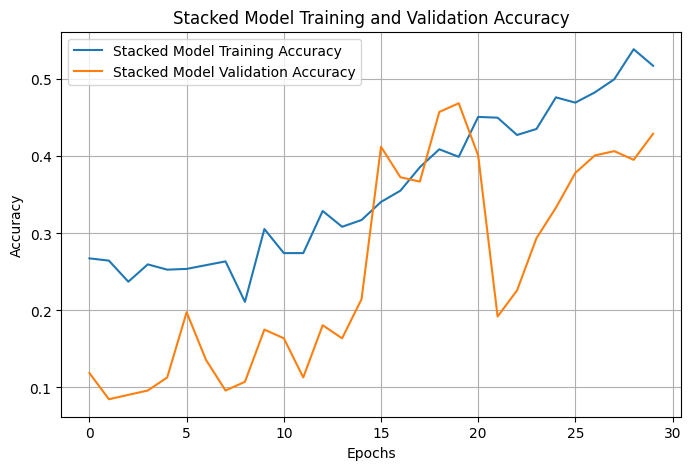

In [18]:
#Plot training and validation loss
plt.figure(figsize=(8, 5))
plt.plot(history_best[0]['loss'], label='Base Model Training Loss')
plt.plot(history_best[0]['val_loss'], label='Base Model Validation Loss')
plt.title('Base Model Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# (Optional) Plot accuracy as well
plt.figure(figsize=(8, 5))
plt.plot(history_best[0]['accuracy'], label='Base Model Training Accuracy')
plt.plot(history_best[0]['val_accuracy'], label='Base Model Validation Accuracy')
plt.title('Base Model Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()



# Plot training and validation loss
plt.figure(figsize=(8, 5))
plt.plot(history_best[1]['loss'], label='Stacked Model Training Loss')
plt.plot(history_best[1]['val_loss'], label='Stacked Model Validation Loss')
plt.title('Stacked Model Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# (Optional) Plot accuracy as well
plt.figure(figsize=(8, 5))
plt.plot(history_best[1]['accuracy'], label='Stacked Model Training Accuracy')
plt.plot(history_best[1]['val_accuracy'], label='Stacked Model Validation Accuracy')
plt.title('Stacked Model Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()




## Task 6: Transformers

In [18]:

torch.cuda.is_available()

False

In [ ]:

wandb.login()

wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

In [ ]:
WANDB_USER = "faezeh-sarlakifar"

In [ ]:


# Convert train/valid/test to HuggingFace Dataset
train_texts = train["tweet"].values
train_labels = train["labels"].values

valid_texts = val["tweet"].values
valid_labels = val["labels"].values

test_texts = test["tweet"].values
test_labels = test["labels"].values

train_ds = Dataset.from_dict({
    "text": train_texts.tolist(),
    "labels": train_labels.tolist()
})

valid_ds = Dataset.from_dict({
    "text": valid_texts.tolist(),
    "labels": valid_labels.tolist()
})

test_ds = Dataset.from_dict({
    "text": test_texts.tolist(),
    "labels": test_labels.tolist()
})

In [ ]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def evaluate(model, loader, device):
    model.eval()
    preds, trues, losses = [], [], []

    criterion = nn.CrossEntropyLoss()

    with torch.no_grad():
        for batch in loader:
            batch = {k: v.to(device) for k,v in batch.items()}
            outputs = model(**batch)
            logits = outputs.logits
            loss = criterion(logits, batch["labels"])

            losses.append(loss.item())

            pred = torch.argmax(logits, dim=1)
            preds.extend(pred.cpu().numpy())
            trues.extend(batch["labels"].cpu().numpy())

    avg_loss = np.mean(losses)
    acc = accuracy_score(trues, preds)
    f1 = f1_score(trues, preds, average="macro")

    return avg_loss, acc, f1, preds, trues

seeds = [42, 123, 2025]
task = "hate"
MODEL = f"cardiffnlp/twitter-roberta-base-{task}"

tokenizer = AutoTokenizer.from_pretrained(MODEL)

def tokenize(batch):
    return tokenizer(batch["text"], padding="max_length", truncation=True, max_length=128)

columns = ["input_ids", "attention_mask", "labels"]

train_ds = train_ds.map(tokenize, batched=True)
valid_ds = valid_ds.map(tokenize, batched=True)
test_ds  = test_ds.map(tokenize, batched=True)

train_ds.set_format(type="torch", columns=columns)
valid_ds.set_format(type="torch", columns=columns)
test_ds.set_format(type="torch", columns=columns)

for seed in seeds:

    print("\n" + "="*60)
    print(f"Training with SEED = {seed}")
    print("="*60)

    set_seed(seed)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # fresh model every seed
    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL,
        num_labels=4,
        ignore_mismatched_sizes=True
    ).to(device)

    train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
    valid_loader = DataLoader(valid_ds, batch_size=32)
    test_loader  = DataLoader(test_ds,  batch_size=32)

    epochs = 5
    lr = 2e-5

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    total_steps = len(train_loader) * epochs
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=int(0.1 * total_steps),
        num_training_steps=total_steps
    )

    criterion = nn.CrossEntropyLoss()

    wandb.init(
        project="sexism_detection",
        name=f"roberta_seed_{seed}",
        config={
            "seed": seed,
            "model": MODEL,
            "epochs": epochs,
            "lr": lr,
            "batch_size": 16,
        }
    )

    # Training loop
    for epoch in range(epochs):
        model.train()
        total_train_loss = 0
        train_preds, train_trues = [], []

        for batch in train_loader:
            batch = {k: v.to(device) for k,v in batch.items()}

            optimizer.zero_grad()
            outputs = model(**batch)
            loss = outputs.loss

            logits = outputs.logits
            pred = torch.argmax(logits, dim=1)

            train_preds.extend(pred.cpu().numpy())
            train_trues.extend(batch["labels"].cpu().numpy())

            loss.backward()
            optimizer.step()
            scheduler.step()

            total_train_loss += loss.item()

        train_loss = total_train_loss / len(train_loader)
        train_acc = accuracy_score(train_trues, train_preds)
        train_f1  = f1_score(train_trues, train_preds, average="macro")

        # Validation metrics
        val_loss, val_acc, val_f1, _, _ = evaluate(model, valid_loader, device)

        wandb.log({
            "train_loss": train_loss,
            "train_acc": train_acc,
            "train_f1": train_f1,
            "val_loss": val_loss,
            "val_acc": val_acc,
            "val_f1": val_f1,
            "epoch": epoch
        })

        print(
            f"[Seed {seed}] Epoch {epoch+1}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Train F1: {train_f1:.4f} | "
            f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | Val F1: {val_f1:.4f}"
        )
    test_loss, test_acc, test_f1, test_preds, test_trues = evaluate(model, test_loader, device)

    print("\n=== Final Test Results (Seed", seed, ") ===")
    print("Test Loss:", test_loss)
    print("Test Acc :", test_acc)
    print("Test F1  :", test_f1)
    print(classification_report(test_trues, test_preds))

    wandb.log({
        "test_loss": test_loss,
        "test_acc": test_acc,
        "test_f1": test_f1
    })

    # Save per-seed model
    save_dir = f"roberta-hate-finetuned-seed{seed}"
    model.save_pretrained(save_dir)
    tokenizer.save_pretrained(save_dir)

    wandb.finish()

    print(f"Model saved to: {save_dir}/")

In [ ]:
def plot_learning_curve(wandb_run_path, plot_type, seed):
    api = wandb.Api()
    run = api.run(wandb_run_path)

    # Fetch the run history (all logged metrics over time)
    df = run.history()

    train = df[["epoch", f"train_{plot_type}"]].dropna()
    val   = df[["epoch", f"val_{plot_type}"]].dropna()

    # Plot
    plt.figure(figsize=(6,4))
    plt.plot(train["epoch"], train[f"train_{plot_type}"].values, 0.5, label=f"train {plot_type}")
    plt.plot(val["epoch"], val[f"val_{plot_type}"].values, label=f"val {plot_type}")
    plt.xlabel("epoch")
    plt.ylabel(f"{plot_type}")
    plt.legend()
    plt.tight_layout()
    plt.title(f"{plot_type.capitalize()} Train vs Validation for Run with Seed {seed}")
    plt.savefig(f"{plot_type.capitalize()}_seed_{seed}.png", dpi=300)

In [ ]:
plot_learning_curve("faezeh-sarlakifar/sexism_detection/azi7td6j", "f1", "2025")
plot_learning_curve("faezeh-sarlakifar/sexism_detection/foero77l", "f1", "123")
plot_learning_curve("faezeh-sarlakifar/sexism_detection/anwk4krf", "f1", "42")

plot_learning_curve("faezeh-sarlakifar/sexism_detection/azi7td6j", "loss", "2025")
plot_learning_curve("faezeh-sarlakifar/sexism_detection/foero77l", "loss", "123")
plot_learning_curve("faezeh-sarlakifar/sexism_detection/anwk4krf", "loss", "42")

plot_learning_curve("faezeh-sarlakifar/sexism_detection/azi7td6j", "acc", "2025")
plot_learning_curve("faezeh-sarlakifar/sexism_detection/foero77l", "acc", "123")
plot_learning_curve("faezeh-sarlakifar/sexism_detection/anwk4krf", "acc", "42")